In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
RESULT_FILE = "../experiment_results/threshold_experiment_results.csv"
FIG_DIR = "../figs"

os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(RESULT_FILE)

# Remove pandas index column if it exists
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,c_value,T_i,T_o,Average_Power,Average_Response_Time,ERP,Linear_cost_function
0,0.1,0,-6,23998.758425,148.374443,3.560802e+06,24147.132868
1,0.1,0,-5,23998.780270,148.430465,3.562150e+06,24147.210735
2,0.1,0,-4,23998.801578,150.309263,3.607242e+06,24149.110841
3,0.1,0,-3,23998.822936,149.935113,3.598266e+06,24148.758049
4,0.1,0,-2,23998.844521,152.887495,3.669123e+06,24151.732016


In [22]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("c values:", sorted(df["c_value"].unique()))
print("T_i range:", df["T_i"].min(), "to", df["T_i"].max())
print("T_o range:", df["T_o"].min(), "to", df["T_o"].max())

df.describe()

Shape: (216, 7)
Columns: ['c_value', 'T_i', 'T_o', 'Average_Power', 'Average_Response_Time', 'ERP', 'Linear_cost_function']
c values: [np.float64(0.1), np.float64(0.3), np.float64(0.5)]
T_i range: 0 to 5
T_o range: -6 to 5


,c_value,T_i,T_o,Average_Power,Average_Response_Time,ERP,Linear_cost_function
count,216.000000,216.000000,216.000000,216.000000,216.000000,2.160000e+02,216.000000
mean,0.300000,2.500000,-0.500000,23998.581204,86.848651,2.084256e+06,24085.429855
std,0.163679,1.711792,3.460071,0.548522,41.691776,1.000571e+06,41.975906
min,0.100000,0.000000,-6.000000,23996.022177,41.650299,9.995147e+05,24039.429409
25%,0.100000,1.000000,-3.250000,23998.460596,48.918373,1.173955e+06,24047.266479
50%,0.300000,2.500000,-0.500000,23998.819585,70.246613,1.685843e+06,24069.157957
75%,0.500000,4.000000,2.250000,23998.911869,139.311396,3.343333e+06,24138.300295
max,0.500000,5.000000,5.000000,23999.092579,153.295603,3.678929e+06,24152.213168


In [23]:
def plot_heatmap(data, c_value, metric, save=True):
    sub_df = data[data["c_value"] == c_value].copy()

    if sub_df.empty:
        raise ValueError(f"No data found for c = {c_value}")

    pivot_table = sub_df.pivot_table(
        index="T_i",
        columns="T_o",
        values=metric,
        aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        pivot_table.values,
        aspect="auto",
        origin="lower"
    )

    ax.set_xticks(np.arange(len(pivot_table.columns)))
    ax.set_xticklabels(pivot_table.columns)

    ax.set_yticks(np.arange(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)

    ax.set_xlabel("$T_o$ (turn-on threshold)")
    ax.set_ylabel("$T_i$ (turn-off threshold)")
    ax.set_title(f"{metric} heatmap, c = {c_value}")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)

    fig.tight_layout()

    if save:
        output_path = os.path.join(FIG_DIR, f"heatmap_{metric}_c_{c_value}.png")
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print("Saved:", output_path)

    plt.show()


Saved: ../figs\heatmap_Average_Power_c_0.1.png


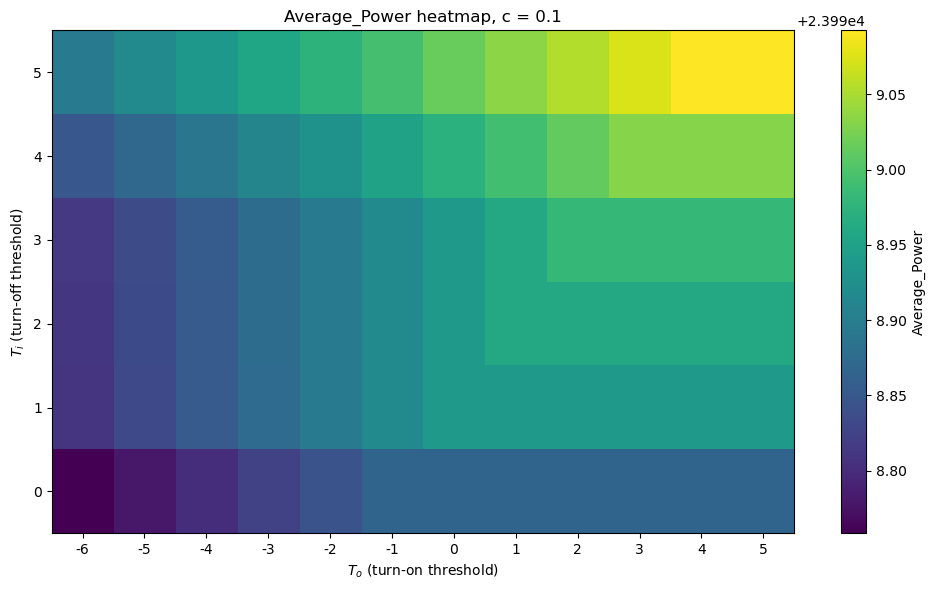

Saved: ../figs\heatmap_Average_Response_Time_c_0.1.png


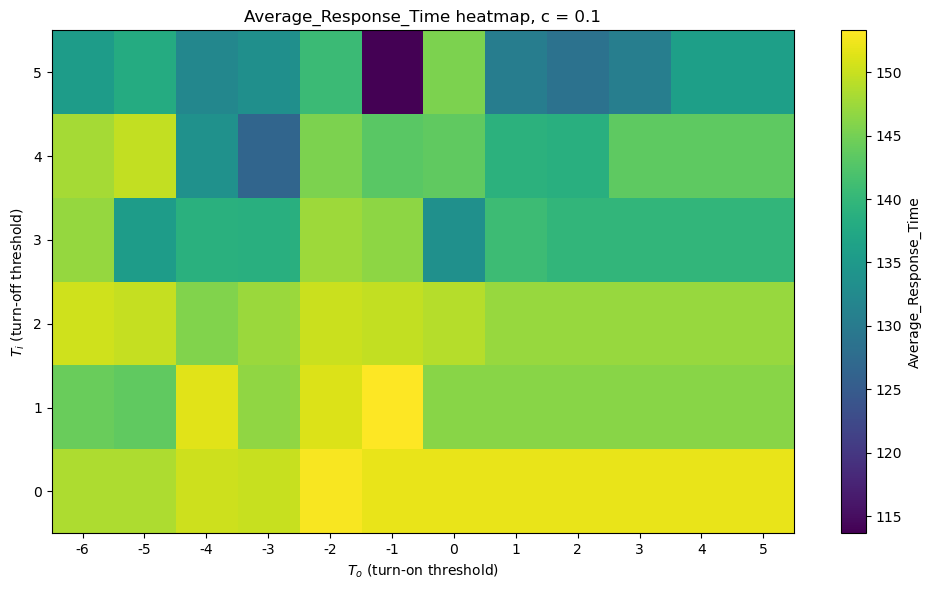

Saved: ../figs\heatmap_ERP_c_0.1.png


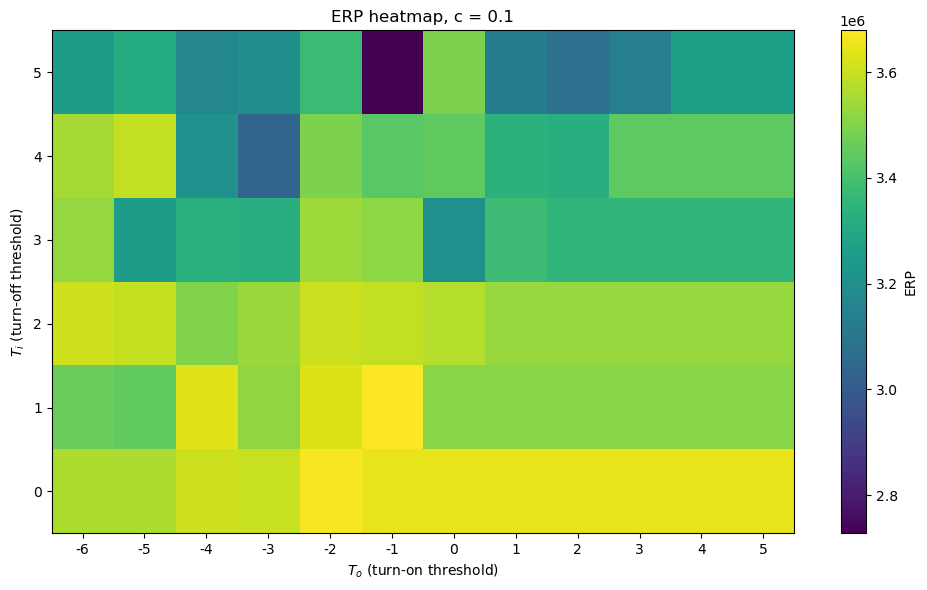

Saved: ../figs\heatmap_Linear_cost_function_c_0.1.png


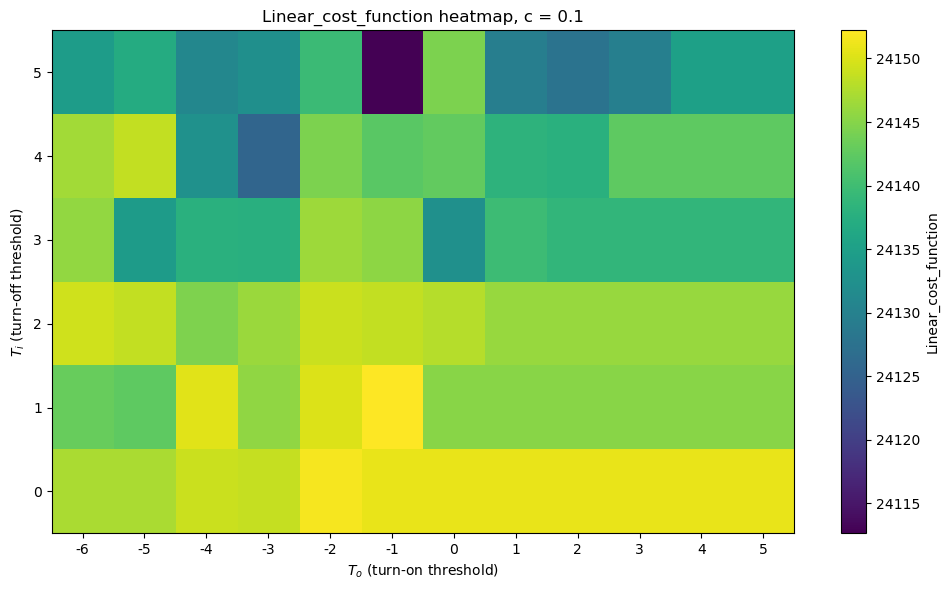

Saved: ../figs\heatmap_Average_Power_c_0.3.png


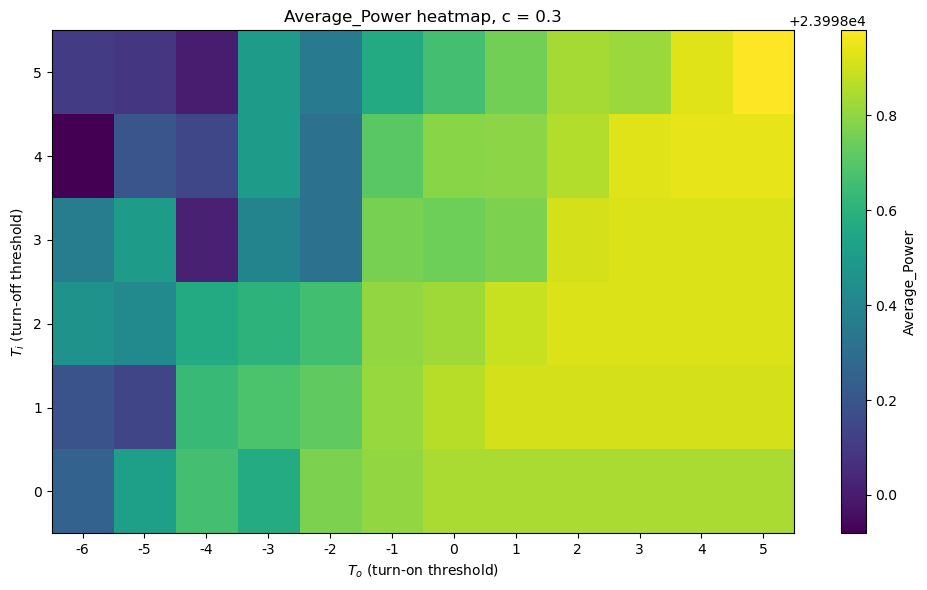

Saved: ../figs\heatmap_Average_Response_Time_c_0.3.png


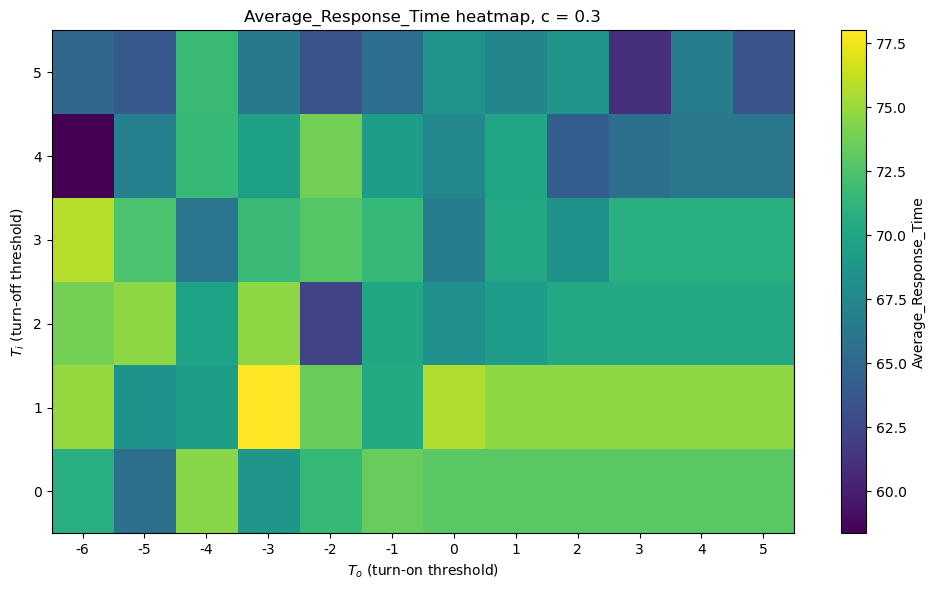

Saved: ../figs\heatmap_ERP_c_0.3.png


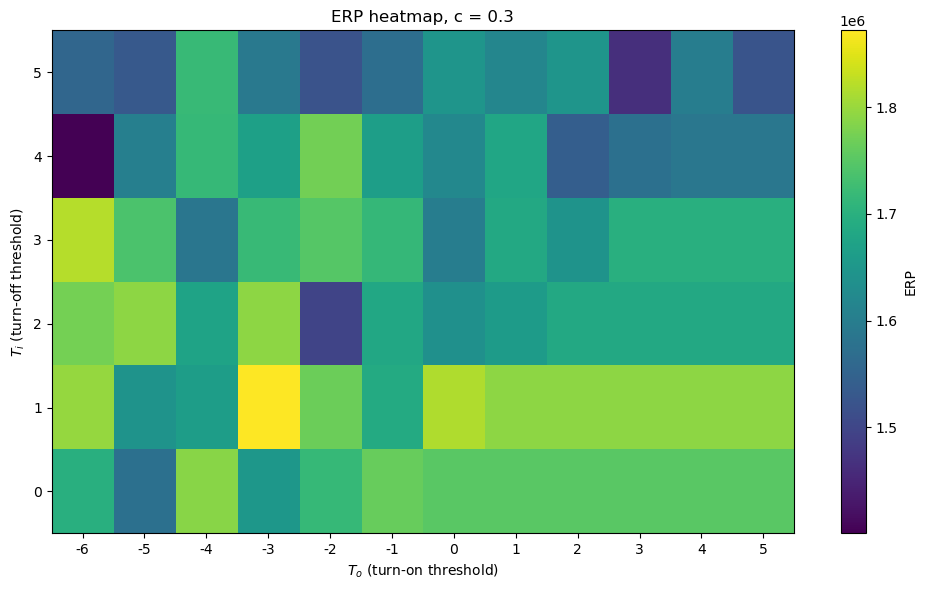

Saved: ../figs\heatmap_Linear_cost_function_c_0.3.png


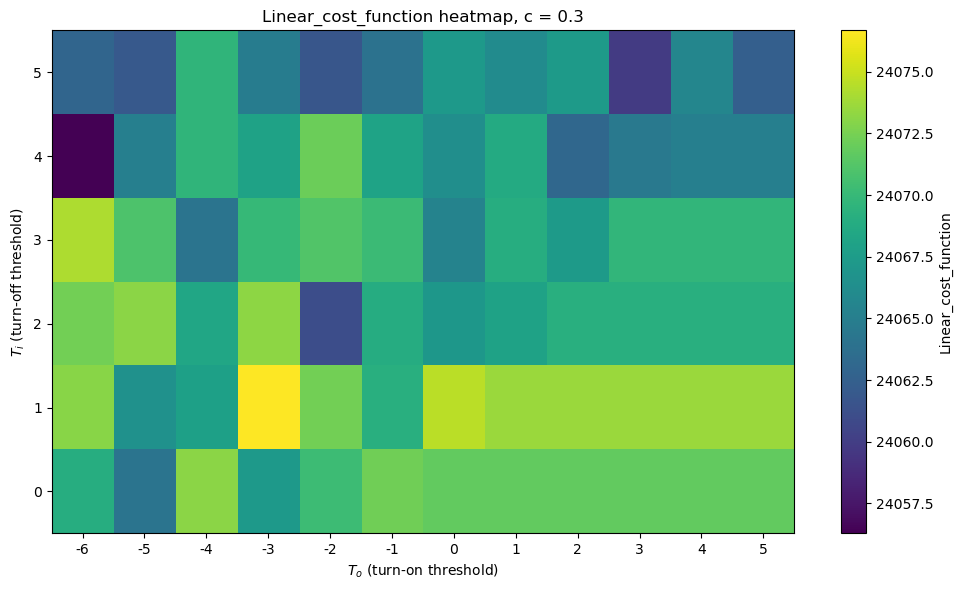

Saved: ../figs\heatmap_Average_Power_c_0.5.png


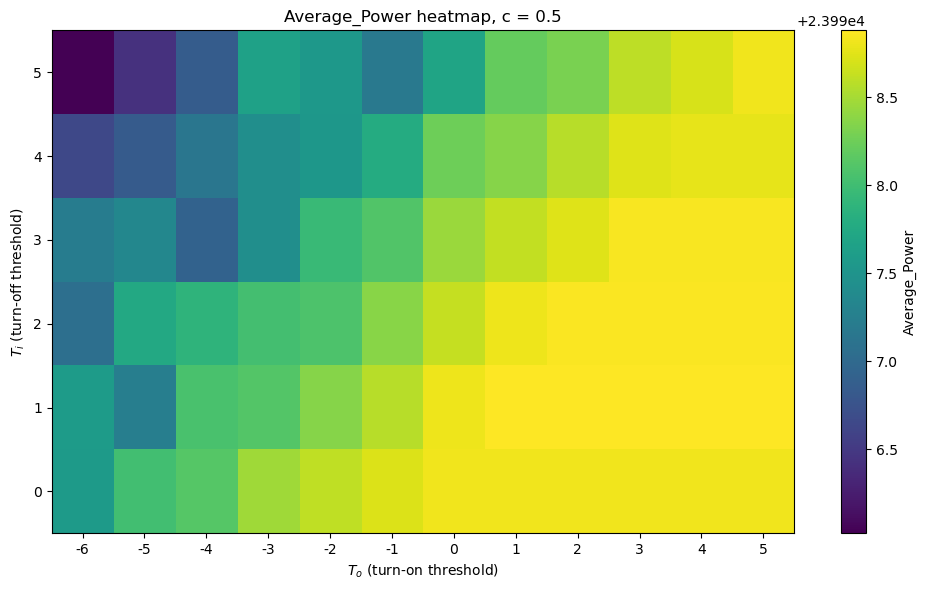

Saved: ../figs\heatmap_Average_Response_Time_c_0.5.png


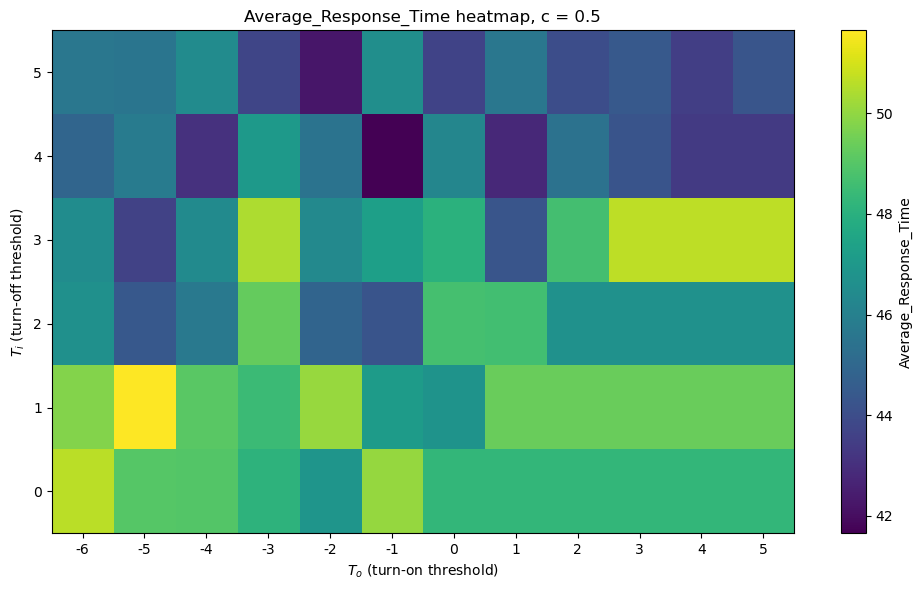

Saved: ../figs\heatmap_ERP_c_0.5.png


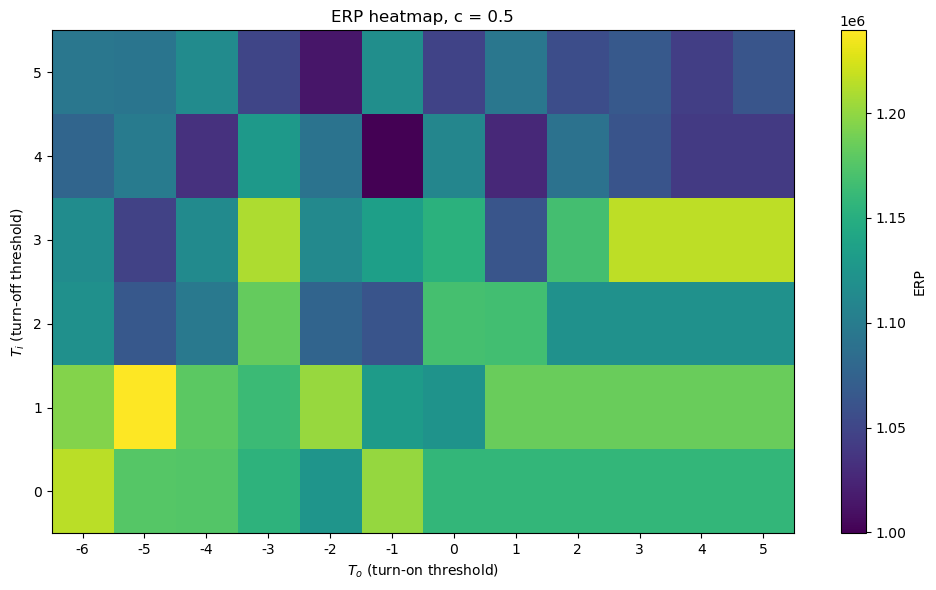

Saved: ../figs\heatmap_Linear_cost_function_c_0.5.png


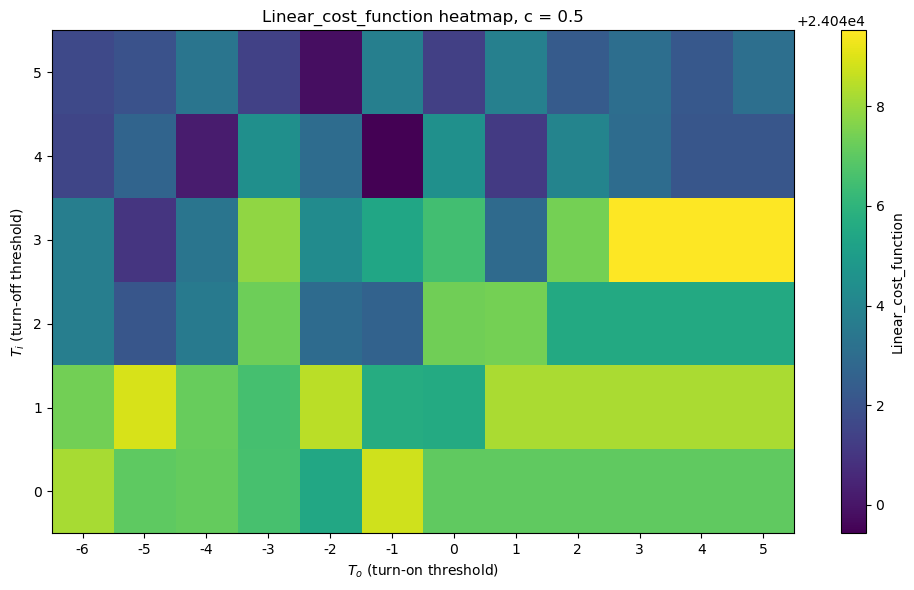

In [24]:
metrics = [
    "Average_Power",
    "Average_Response_Time",
    "ERP",
    "Linear_cost_function"
]

for c_value in sorted(df["c_value"].unique()):
    for metric in metrics:
        plot_heatmap(df, c_value, metric, save=True)
